# 🏈 Fantasy Football Draft Analysis (2024–2025)
*Justin McKendry · August 2025*

---

## 📚 Project Overview

This notebook analyzes player performance, draft value, and team efficiency based on our league's draft and season data.  
We explore who maximized their draft capital, which picks over- or under-performed, and how VORP (Value Over Replacement Player) relates to league standings.

**Key Metrics:**
- 📈 VORP (custom-calculated per position)
- 🎯 Draft Delta (Actual Pick - ADP)
- 💥 Boom/Bust Score (Actual - Projected points)

---

## 🧪 3. Data Analysis

### 🔍 Purpose
Take the data from the SQL Database and Analyze it:
- Calculate VORP (Value Over Replacement Player) - Essentially how useful a player is to a team above the standard at their position.
- Draft Delta - How much of a reach or steal they were in our leagues draft.
- Boom/Bust Score - How much a player exceeded expectations
- Final standings - How a team finished


### Import Packages 

In [3]:
import pandas as pd 
import plotly.graph_objects as go

from numpy.polynomial.polynomial import Polynomial
import numpy as np

import plotly.express as px
import scipy.stats as stats


# Visualise the distribution of comments per post
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

# --- Configuration for Jupyter ---
# The following magic command is for Jupyter notebooks to render plots inline.
# It should be commented out when running as a standalone script.
%config InlineBackend.figure_formats = ['svg']


### Pull From SQL Database

**Objective:**
The goal of this section is to determine which drafted players in my league provided the most value in fantasy football by calculating Value Over Replacement Player (VORP). This metric estimates how many more points a player scored compared to a “replacement-level” player at the same position.


**Methodology:**
Identify Replacement-Level Benchmarks
To simulate “freely available” players, I calculated the average points per game (PPG) for each position at the fringe of a 14-team league’s starting range.

Replacement-Level Cutoffs
These represent the positional ranks just outside typical starter thresholds:

🧠 QB: Positional Ranks 15–18

🏃 RB: Ranks 29–32

🧤 WR: Ranks 29–32 (includes FLEX players via slot IDs 4 & 23)

🧱 TE: Ranks 15–16

🦵 K & D/ST: Ranks 15–18

Account for Lineup Slot Variations
Players may be assigned different lineupSlotIds depending on roster settings.
For example, QBs may appear as Slot ID 0 or 20, and both were included in the QB pool for replacement-level benchmarks.



In [4]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

In [21]:
def calculate_all_vorp(engine, year):
    query = """
    WITH qb_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats
        WHERE (lineupSlotId = 20 OR lineupSlotId = 0) AND posRank BETWEEN 15 AND 18
          AND year = :year
    ),
    rb_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats 
        WHERE lineupSlotId = 2 AND posRank BETWEEN 29 AND 32
          AND year = :year
    ),
    wr_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats 
        WHERE (lineupSlotId = 4 OR lineupSlotId = 23) AND posRank BETWEEN 29 AND 32
          AND year = :year
    ),
    te_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats 
        WHERE lineupSlotId = 6 AND posRank BETWEEN 15 AND 16
          AND year = :year
    ),
    k_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats 
        WHERE lineupSlotId = 17 AND posRank BETWEEN 15 AND 18
          AND year = :year
    ),
    dst_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players_stats 
        WHERE lineupSlotId = 16 AND posRank BETWEEN 15 AND 18
          AND year = :year
    )

    SELECT 
        d.player_id,
        p.player_name,
        s.posRank,
        s.points,
        s.games_played,
        t.team_name,
        a.position,
        s.avg_points,
        s.projected_points,
        (s.points - s.projected_points) AS boom_bust,
        d.lineupSlotId,
        d.roundPickNumber,
        d.overallPickNumber,
        s.pro_team,
        a.avg,
        t.final_standing,
        t.draft_projected_rank,
        (d.overallPickNumber - a.avg) AS draft_delta,
        d.roundId,
        ROUND(
            CASE 
                WHEN d.lineupSlotId IN (0,20) THEN ((SELECT ppg FROM qb_replacement))
                WHEN d.lineupSlotId = 2 THEN ((SELECT ppg FROM rb_replacement))
                WHEN d.lineupSlotId IN (4,23) THEN s.points - ((SELECT ppg FROM wr_replacement))
                WHEN d.lineupSlotId = 6 THEN s.points - ((SELECT ppg FROM te_replacement))
                WHEN d.lineupSlotId = 17 THEN s.points - ((SELECT ppg FROM k_replacement))
                WHEN d.lineupSlotId = 16 THEN s.points - ((SELECT ppg FROM dst_replacement))
                ELSE NULL
            END
        , 2) AS vorp
    FROM drafts d
    JOIN players p ON d.player_id = p.player_id
    JOIN players_stats s 
         ON d.player_id = s.player_id 
        AND d.year = s.year
    JOIN teams t 
         ON d.team_id = t.team_id
        AND d.year = t.year
    JOIN average_draft_position a 
         ON d.player_id = a.player_id 
        AND d.year = a.year
    WHERE s.points IS NOT NULL
      AND d.year = :year
    ORDER BY vorp DESC
    """
    return pd.read_sql(query, engine, params={"year": year})


In [20]:
heatmap_df = calculate_all_vorp(engine, 2024)
heatmap_df[heatmap_df['position'] == 'DST']

,player_id,player_name,posRank,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,pro_team,avg,final_standing,draft_projected_rank,draft_delta,roundId,vorp
91,-16015,Dolphins D/ST,24,66.0,17.0,Mission Viejo Goat,DST,3.88,120.47,-54.47,20,4,200,MIA,166.3,9,13,33.7,15,163.04
99,-16030,Jaguars D/ST,31,39.0,17.0,Mendes Army,DST,2.29,109.60,-70.60,20,13,209,JAX,236.0,3,6,-27.0,15,163.04
191,-16023,Steelers D/ST,4,130.0,17.0,Mendes Army,DST,7.65,118.29,11.71,16,2,156,PIT,156.3,3,6,-0.3,12,-33.04
193,-16021,Eagles D/ST,6,119.0,17.0,South Bay Starr Power,DST,7.00,105.69,13.31,16,14,140,PHI,179.3,8,9,-39.3,10,-44.04
195,-16024,Chargers D/ST,7,117.0,17.0,Stretchy Pups Elite,DST,6.88,89.65,27.35,16,3,171,LAC,247.3,4,12,-76.3,13,-46.04
196,-16002,Bills D/ST,8,116.0,17.0,Joemomma,DST,6.82,85.22,30.78,16,5,131,BUF,189.3,13,14,-58.3,10,-47.04
203,-16008,Lions D/ST,10,105.0,17.0,Flying Eagles,DST,6.18,108.65,-3.65,16,10,164,DET,206.3,5,5,-42.3,12,-58.04
204,-16033,Ravens D/ST,11,101.0,17.0,Deb’s Debsters,DST,5.94,128.58,-27.58,16,7,133,BAL,129.0,6,11,4.0,10,-62.04
205,-16003,Bears D/ST,11,101.0,17.0,B Mac,DST,5.94,112.06,-11.06,16,6,216,CHI,217.3,14,1,-1.3,16,-62.04
207,-16012,Chiefs D/ST,14,93.0,17.0,Luke's Cool Guys,DST,5.47,106.68,-13.68,16,2,170,KC,164.3,11,7,5.7,13,-70.04


### Analyze the heatmap_df

In [124]:
## Get the position Rank. Basically how many points they scored relative to other players in their position

heatmap_df['posRank'] = (
    heatmap_df.groupby('position')['points']
    .rank(method='min', ascending=False)
    .astype(int)
)
heatmap_df.columns

Index(['player_id', 'player_name', 'points', 'games_played', 'team_name',
       'position', 'avg_points', 'projected_points', 'boom_bust',
       'lineupSlotId', 'roundPickNumber', 'overallPickNumber', 'pro_team',
       'avg', 'final_standing', 'draft_projected_rank', 'draft_delta',
       'roundId', 'vorp', 'posRank'],
      dtype='object')

#### Pull the total VORP per position

In [105]:
## Number of starters in each position
N = {
    'QB': 14,
    'RB': 28,
    'WR': 28,
    'TE': 14,
    'K': 14,
    'DST': 14
}
# Filter to top N players per position (e.g., top 12 QBs, 24 RBs, etc.)
# Filter to top N players per position (e.g., top 12 QBs, 24 RBs, etc.)
top_players = (
    heatmap_df.groupby('position')
    .apply(lambda x: x.nlargest(N[x.name], 'vorp'))
    .reset_index(drop=True)  # <-- removes the hierarchical index
)
# Calculates the total vorp by position
total_vorp_by_position = (
    top_players.groupby('position')['vorp']
    .sum()
    .sort_values(ascending=False)
)
total_vorp_by_position

/var/folders/z9/9ssv5sps079cjvmsgkqm93w00000gn/T/ipykernel_23769/1204406362.py:14: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



position
RB     1898.02
QB     1824.32
WR     1729.26
K       -68.87
DST    -279.15
TE     -740.52
Name: vorp, dtype: float64

In [106]:
# Makes that into a dictionary for a chart later on
position_vorp_dict = total_vorp_by_position.to_dict()
position_vorp_dict


{'RB': 1898.02,
 'QB': 1824.32,
 'WR': 1729.26,
 'K': -68.86999999999999,
 'DST': -279.15,
 'TE': -740.52}

## Visualizations

This section translates raw data and calculations into clear, interpretable visuals that support our key analytical questions:

Where did teams find the most draft value?

Did smart drafting correlate with league success?

Which players were breakout steals or costly reaches?

Did those picks pay off relative to expectations?

We use bar charts, heatmaps, and payoff indicators to:

Quantify the effectiveness of draft decisions.

Identify league-wide trends in value and efficiency.

Surface stories (like surprising picks or breakout contributors) that go beyond raw points.

📌 These charts are designed to both support deeper statistical reasoning and present visually compelling narratives that can be shared with a broader audience (e.g., on a website or in a league recap).



### Creating the Heatmap

Goal: Visualize the impact of each draft pick using a heatmap colored by Value Over Replacement Player (VORP).

Why? This allows us to see where teams got the most value in the draft. VORP captures the difference between a player and the best replacement available on waivers.

Design Choice: We used draft round and pick position to map cells and VORP as color — highlighting the spatial dynamics of drafting success.

📌 This answers: “Who consistently found value across the board vs. who missed?”

In [107]:
pivot_score = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='vorp')
pivot_player = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='player_name')
pivot_position = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='position')
pivot_points = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='points')
pivot_teams = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='team_name')


# Build hover text
hover_text = (
    '<b>' + pivot_player.fillna('') + '</b><br>' +
    'Pos: ' + pivot_position.fillna('') + '<br>' +
    'VORP: ' + pivot_score.round(2).astype(str) + '<br>' +
    'Points: ' + pivot_points.fillna(0).astype(int).astype(str) + '<br>' + 
    'Team: ' + pivot_teams.fillna('NA').astype(str)
)

# Create Heatmap
fig = go.Figure(data=go.Heatmap(
    z=pivot_score.values,
    x=pivot_score.columns,
    y=pivot_score.index,
    text=hover_text.values,
    hoverinfo="text",
    colorscale='RdYlGn',
    zmin=pivot_score.min().min(),
    zmax=pivot_score.max().max(),
    showscale=True,
    colorbar=dict(title="VORP"),
))

# Add text in center of each box (VORP)
for i in range(len(pivot_score.index)):
    for j in range(len(pivot_score.columns)):
        value = pivot_score.iloc[i, j]
        if pd.notnull(value):
            fig.add_annotation(
                text=f"{value:.1f}",
                x=pivot_score.columns[j],
                y=pivot_score.index[i],
                showarrow=False,
                font=dict(color="black", size=10),
                xanchor="center",
                yanchor="middle"
            )

# Layout adjustments
fig.update_layout(
    title="VORP",
    xaxis=dict(title="Draft Round", side='top', tickmode='linear', dtick=1),
    yaxis=dict(title="Pick Number in Round", autorange='reversed', tickmode='linear', dtick=1),
    width=1000,
    height=700,
    plot_bgcolor='white'
)

fig.write_html("../docs/charts/draft_value_chart.html")
fig.show()


###

#### Create a chart showing how VORP evolves as the draft goes on

Goal: Understand whether earlier picks tend to have higher VORP or if value is distributed more evenly.

Method: We group by draft pick number and compute the average VORP at each position.

Rationale: Helps justify why certain draft rounds are more important than others and gives evidence for cutting off deeper rounds in steal/reach analysis.

📌 Helps answer: “Is early draft position predictive of long-term value?”

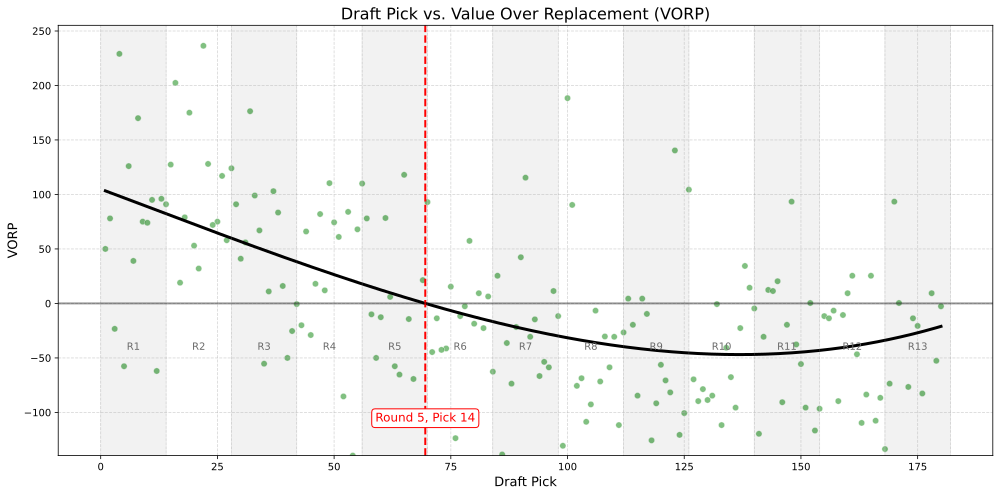

In [108]:
df = heatmap_df.dropna(subset=["overallPickNumber", "vorp"])
x = df["overallPickNumber"]
y = df["vorp"]

# Fit trend line (degree 3 polynomial)
coeffs = Polynomial.fit(x, y, 3).convert().coef
x_vals = np.linspace(x.min(), x.max(), 500)
y_vals = np.polyval(coeffs[::-1], x_vals)

# Find x-intercept
roots = np.roots(coeffs[::-1])
real_roots = [r.real for r in roots if r.imag == 0 and r.real > 0]
x_intercept = min(real_roots) if real_roots else None

# Get round/pick info
teams_per_round = 14
if x_intercept:
    round_num = int(x_intercept // teams_per_round) + 1
    pick_num = int(x_intercept % teams_per_round) + 1
    label_text = f"Round {round_num}, Pick {pick_num}"

# Plot
plt.figure(figsize=(14, 7))
sns.scatterplot(x=x, y=y, color="green", s=40, alpha=0.7)
plt.plot(x_vals, y_vals, color="black", linewidth=3)

# Shade and label rounds
max_pick = int(x.max())
for r in range((max_pick // teams_per_round) + 1):
    start = r * teams_per_round
    end = start + teams_per_round
    color = "lightgray" if r % 2 == 0 else "white"
    plt.axvspan(start, end, color=color, alpha=0.3)

    # Optional vertical line between rounds
    plt.axvline(x=end, color="gray", linestyle=":", linewidth=0.5)

    # Round label centered
    plt.text(
        start + teams_per_round / 2,
        -40,  # below x-axis
        f"R{r+1}",
        ha="center",
        va="center",
        fontsize=10,
        color="dimgray"
    )

# Annotate intersection point
if x_intercept:
    plt.axvline(x=x_intercept, color="red", linestyle="--", linewidth=2)
    plt.text(
        x_intercept,
        -100,
        label_text,
        ha="center",
        va="top",
        color="red",
        fontsize=12,
        bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3')
    )

# Final styling
plt.xlabel("Draft Pick", fontsize=13)
plt.ylabel("VORP", fontsize=13)
plt.title("Draft Pick vs. Value Over Replacement (VORP)", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(bottom=min(y.min(), -110))  # space for annotation + round labels
# Emphasize horizontal 0 line
plt.axhline(y=0, color="black", linewidth=2,alpha=0.4)
plt.tight_layout()
plt.savefig("../docs/charts/draft_pick_vs_vorp.png")
plt.show()

#### Generate a dataframe with avg_vorp per team and their final standing to place in a chart

Goal: Create a structured table for analyzing team-level draft performance.

Why? Average VORP summarizes how well a team drafted across all rounds.

Method: Group all drafted players by team and compute the mean VORP, then merge with final standings.

📌 This prepares data for visual correlation between draft performance and season outcome.

In [109]:
df_clean = df[df['vorp'].notnull()]

# Compute average VORP by team
avg_vorp_df = (
    df_clean
    .groupby('team_name')['vorp']
    .mean()
    .reset_index()
    .rename(columns={'vorp': 'avg_vorp'})
)

# Merge final standings for correlation analysis
avg_vorp_df = avg_vorp_df.merge(
    heatmap_df[['team_name', 'final_standing']].drop_duplicates(),
    on='team_name',
    how='left'
)

avg_vorp_df.sort_values('avg_vorp',ascending=False)

,team_name,avg_vorp,final_standing
5,Luke's Cool Guys,16.960667,4
11,The Ralph Dudes,15.074286,7
7,Mission Viejo Goat,7.894000,2
3,Husky Express,5.560000,3
6,Mendes Army,2.693333,10
0,Ambler Thighs,0.360000,9
1,Flying Eagles,-3.174000,6
4,Jean Machine,-5.772667,5
2,Gerald Pea's Football Team,-7.774000,8
9,Stretchy Pups Elite,-8.997857,1


#### Generate a graph displaying the average VORP by team and how they finished

Goal: Explore the relationship between draft efficiency and league results.

Approach: Visualize each team’s average VORP alongside their final rank.

Insight Sought: Do teams who drafted well (high avg VORP) finish at the top? Or is there no strong connection?

📌 Supports strategic review of the draft process and whether smart drafting consistently pays off.

/var/folders/z9/9ssv5sps079cjvmsgkqm93w00000gn/T/ipykernel_23769/2618210151.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




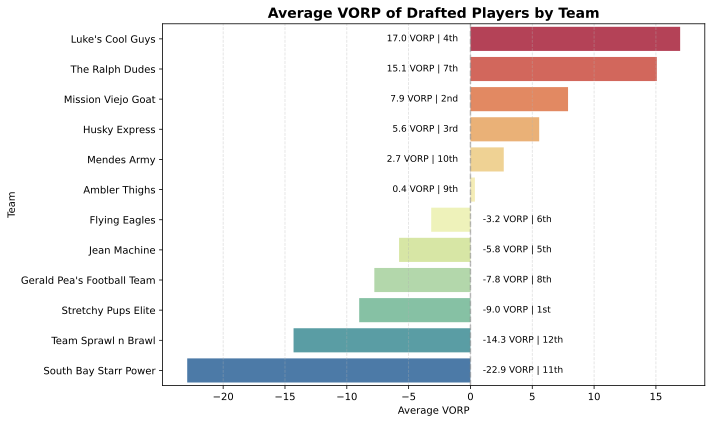

In [110]:

# Define ordinal suffix function
def ordinal(n):
    if 10 <= n % 100 <= 20:
        return f"{n}th"
    else:
        return f"{n}{['th','st','nd','rd','th','th','th','th','th','th'][n%10]}"

# Sort the data used for plotting AND labeling
df_sorted = avg_vorp_df.sort_values("avg_vorp", ascending=False).reset_index(drop=True)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted, y='team_name', x='avg_vorp', palette='Spectral')

# Fix label misalignment by iterating over sorted df
for i, row in df_sorted.iterrows():
    label = f"{row['avg_vorp']:.1f} VORP | {ordinal(int(row['final_standing']))}"
    
    if row['avg_vorp'] >= 0:
        plt.text(-1, i, label, ha='right', va='center', fontsize=9)
    else:
        plt.text(1, i, label, ha='left', va='center', fontsize=9)

# Beautify
plt.title("Average VORP of Drafted Players by Team", fontsize=14, fontweight='bold')
plt.xlabel("Average VORP")
plt.ylabel("Team")
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("../docs/charts/avg_vorp.png")
plt.show()

#### Verify if there is a correlation between draft VORP and final standings

Goal: Quantify the strength and direction of the relationship between draft performance and league outcome.

Metric: We calculate the Pearson correlation coefficient between avg_vorp and final_standing.

Why this matters: This is the statistical backbone of the earlier visualizations. If there’s no correlation, then draft performance may not matter as much as in-season moves or luck.

📌 Directly answers: “Does good drafting statistically lead to winning?”

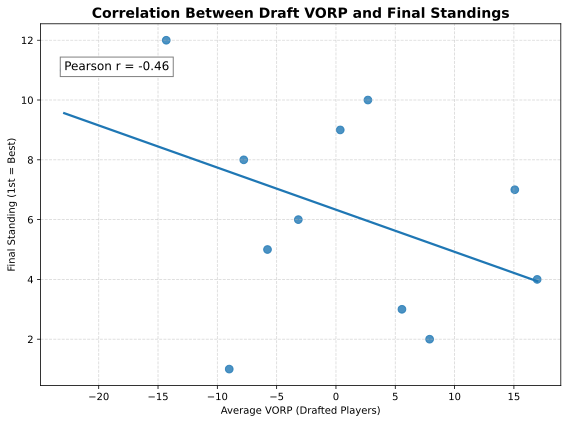

In [111]:
# Calculate correlation
r, p = stats.pearsonr(avg_vorp_df['avg_vorp'], avg_vorp_df['final_standing'])

plt.figure(figsize=(8, 6))
sns.regplot(data=avg_vorp_df, x='avg_vorp', y='final_standing', ci=None, scatter_kws={'s': 60})

# Annotate with r value
plt.title("Correlation Between Draft VORP and Final Standings", fontsize=14, fontweight='bold')
plt.xlabel("Average VORP (Drafted Players)")
plt.ylabel("Final Standing (1st = Best)")

plt.text(avg_vorp_df['avg_vorp'].min(), avg_vorp_df['final_standing'].max() - 1,
         f"Pearson r = {r:.2f}", fontsize=12, bbox=dict(facecolor='white', edgecolor='gray'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("../docs/charts/corr_vorp_standings.png")
plt.show()

#### Get the Reaches and Steals of the Leagues Draft

Filter before round 8 as after that round VORP becomes negative. This means that it is just as valuable to pick a player up off of the waiver wire to replace a player that you drafted in this round. 

In [112]:
# Step 1: Filter to rounds 1–5 as after that round VORP falls below negative
early_df = heatmap_df[(heatmap_df['roundId'] < 8) & (heatmap_df['draft_delta'].notnull())].copy()

# Step 2: Top 10 steals (drafted much later than ADP)
steals = early_df.sort_values('draft_delta', ascending=False).head(10).copy()
steals['label'] = steals['player_name'] + " (" + steals['team_name'] + ")"

# Step 3: Top 10 reaches (drafted much earlier than ADP)
reaches = early_df.sort_values('draft_delta', ascending=True).head(10).copy()
reaches['label'] = reaches['player_name'] + " (" + reaches['team_name'] + ")"

In [113]:
columns_to_show = ['player_name', 'team_name', 'position', 'points', 'vorp']

# Top 10 VORP
top_vorp = (
    heatmap_df[heatmap_df['vorp'].notnull()]
    .sort_values('vorp', ascending=False)
    .head(10)[columns_to_show]
    .reset_index(drop=True)
)

# Bottom 10 VORP
bottom_vorp = (
    heatmap_df[heatmap_df['vorp'].notnull()]
    .sort_values('vorp', ascending=True)
    .head(10)[columns_to_show]
    .reset_index(drop=True)
)

# Apply formatting to top table
top_html = (
    top_vorp.style
    .set_caption("Top 10 Draft Steals by VORP")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('font-size', '16px')]
    }])
    .format({'points': '{:.1f}', 'vorp': '{:.1f}'})
    .to_html()
)

# Apply formatting to bottom table
bottom_html = (
    bottom_vorp.style
    .set_caption("Bottom 10 Draft Busts by VORP")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('font-size', '16px')]
    }])
    .format({'points': '{:.1f}', 'vorp': '{:.1f}'})
    .to_html()
)
# Save to HTML files
with open("../docs/tables/top_vorp_table.html", "w") as f:
    f.write(top_html)

with open("../docs/tables/bottom_vorp_table.html", "w") as f:
    f.write(bottom_html)


##### Create the Draft Steals Chart

These are players that were taken later then they were suppose to 

/var/folders/z9/9ssv5sps079cjvmsgkqm93w00000gn/T/ipykernel_23769/3985294427.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




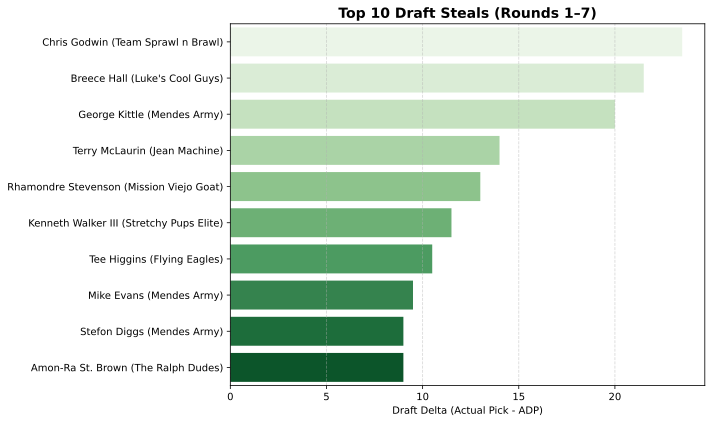

In [114]:
plt.figure(figsize=(10, 6))
sns.barplot(data=steals, y='label', x='draft_delta', palette='Greens')

plt.title("Top 10 Draft Steals (Rounds 1–7)", fontsize=14, fontweight='bold')
plt.xlabel("Draft Delta (Actual Pick - ADP)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("../docs/charts/steals_og.png")
plt.show()

#### Create the Draft Reaches Chart
These are players taken earlier then they were supposed to 

/var/folders/z9/9ssv5sps079cjvmsgkqm93w00000gn/T/ipykernel_23769/697193947.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




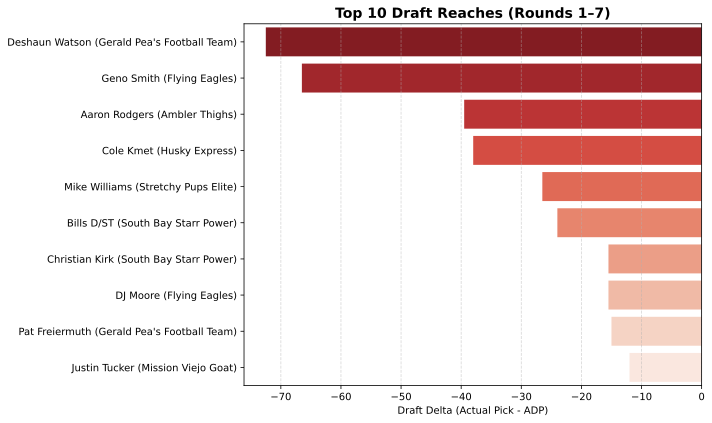

In [115]:
plt.figure(figsize=(10, 6))
sns.barplot(data=reaches, y='label', x='draft_delta', palette='Reds_r')

plt.title("Top 10 Draft Reaches (Rounds 1–7)", fontsize=14, fontweight='bold')
plt.xlabel("Draft Delta (Actual Pick - ADP)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("../docs/charts/reaches_og.png")
plt.show()

#### Create a column to see if those steals/reaches paid off

This column evaluates whether a drafted player exceeded expectations by comparing their actual fantasy points to their projected points at the time of the draft.
If the actual performance is greater than the projection, we consider the pick as having “paid off.” This binary label will later be used for color-coding steals and reaches in visualizations.



In [116]:
# Add more evaluation columns to each steal/reach DataFrame
eval_cols = ['player_name', 'team_name', 'position', 'roundId', 'avg', 'overallPickNumber', 
             'draft_delta', 'points', 'projected_points', 'boom_bust', 'vorp', 'posRank']


steals_eval = steals[eval_cols].copy()
reaches_eval = reaches[eval_cols].copy()

# Add simple binary payoff labels
steals['paid_off'] = (steals_eval['vorp'] > 0) & (steals_eval['boom_bust'] >= 0)
reaches['paid_off'] = (reaches_eval['vorp'] > 0) & (reaches_eval['boom_bust'] >= 0)

#### Create tables to display on the website

This section generates two tables:

Top 10 Steals: Players with the largest positive draft delta (ADP was much lower than where they were picked).

Top 10 Reaches: Players picked significantly earlier than their ADP.

The tables are styled using pandas.DataFrame.style and exported as HTML so they can be embedded directly into the project’s web interface.



In [117]:
heatmap_df.sort_values(by='draft_projected_rank', ascending=True)

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,pro_team,avg,final_standing,draft_projected_rank,draft_delta,roundId,vorp,posRank
0,3918298,Josh Allen,376.0,17.0,Mission Viejo Goat,QB,22.12,0.0,376.0,0,10,22,BUF,20.0,2,1,2.0,2,236.38,1
7,3046779,Jared Goff,280.0,17.0,Mission Viejo Goat,QB,16.47,0.0,280.0,20,3,123,DET,150.5,2,1,-27.5,11,140.38,5
24,4379399,James Cook,173.0,17.0,Mission Viejo Goat,RB,10.18,0.0,173.0,2,10,70,BUF,71.5,2,1,-1.5,6,93.00,11
44,4241478,DeVonta Smith,138.0,16.0,Mission Viejo Goat,WR,8.62,0.0,138.0,4,3,27,PHI,28.5,2,1,-1.5,3,58.00,20
60,4569173,Rhamondre Stevenson,98.0,12.0,Mission Viejo Goat,RB,8.17,0.0,98.0,2,10,46,NE,33.0,2,1,13.0,4,18.00,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,4372485,Rondale Moore,55.0,17.0,Ambler Thighs,WR,3.24,0.0,55.0,20,7,115,ATL,155.5,9,12,-40.5,10,-84.63,51
137,3121023,Dallas Goedert,73.0,14.0,Ambler Thighs,TE,5.21,0.0,73.0,6,7,67,PHI,60.0,9,12,7.0,6,-69.33,10
143,4360294,Antonio Gibson,64.0,16.0,Ambler Thighs,RB,4.00,0.0,64.0,20,6,102,NE,105.0,9,12,-3.0,9,-75.63,36
166,3116164,Mike Gesicki,30.0,17.0,Ambler Thighs,TE,1.76,0.0,30.0,20,7,163,CIN,234.0,9,12,-71.0,14,-109.63,18


In [118]:
from IPython.display import display

print("💸 Draft Steals (Rounds 1–7): Did They Pay Off?")
display(steals[['player_name', 'team_name', 'draft_delta', 'vorp', 'boom_bust', 'paid_off']])

print("💰 Draft Reaches (Rounds 1–7): Did They Pay Off?")
display(reaches[['player_name', 'team_name', 'draft_delta', 'vorp', 'boom_bust', 'paid_off']])

💸 Draft Steals (Rounds 1–7): Did They Pay Off?


,player_name,team_name,draft_delta,vorp,boom_bust,paid_off
103,Chris Godwin,Team Sprawl n Brawl,23.5,-22.63,117.00,False
12,Breece Hall,Luke's Cool Guys,21.5,118.00,198.00,True
95,George Kittle,Mendes Army,20.0,-14.33,128.00,False
92,Terry McLaurin,Jean Machine,14.0,-13.63,126.00,False
60,Rhamondre Stevenson,Mission Viejo Goat,13.0,18.00,98.00,True
34,Kenneth Walker III,Stretchy Pups Elite,11.5,78.00,158.00,True
68,Tee Higgins,Flying Eagles,10.5,11.00,91.00,True
45,Mike Evans,Mendes Army,9.5,57.38,197.00,True
31,Stefon Diggs,Mendes Army,9.0,79.00,159.00,True
11,Amon-Ra St. Brown,The Ralph Dudes,9.0,124.00,57.82,True


💰 Draft Reaches (Rounds 1–7): Did They Pay Off?


,player_name,team_name,draft_delta,vorp,boom_bust,paid_off
127,Deshaun Watson,Gerald Pea's Football Team,-72.5,-57.63,82.00,False
32,Geno Smith,Flying Eagles,-66.5,78.38,218.00,True
177,Aaron Rodgers,Ambler Thighs,-39.5,-139.63,0.00,False
116,Cole Kmet,Husky Express,-38.0,-41.33,101.00,False
120,Mike Williams,Stretchy Pups Elite,-26.5,-50.00,30.00,False
72,Bills D/ST,South Bay Starr Power,-24.0,6.38,146.00,True
73,Christian Kirk,South Bay Starr Power,-15.5,6.00,86.00,True
18,DJ Moore,Flying Eagles,-15.5,103.00,183.00,True
163,Pat Freiermuth,Gerald Pea's Football Team,-15.0,-102.33,-48.87,False
62,Justin Tucker,Mission Viejo Goat,-12.0,15.38,8.82,True


#### Generate plots to show the payoff 
Here we visually explore whether each steal or reach “paid off.”

Players who exceeded their projections are shown in green ✅.

Players who underperformed are shown in red ❌.

This helps illustrate how much risk-taking in the draft either succeeded or failed.

In [119]:
payoff_palette = {True: 'green', False: 'red'}

#### Create the pay off chart for reaches

This chart highlights the Top 10 biggest reaches in the first 8 rounds of the draft, colored by whether those risky early picks were justified:

✅ Green bars = pick exceeded expectations

❌ Red bars = pick did not meet expectations

This visual helps identify which aggressive draft strategies worked and which backfired.

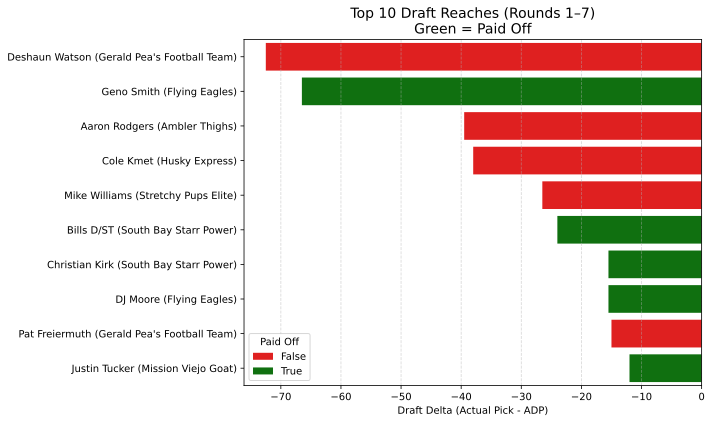

In [120]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=reaches,
    y='label',
    x='draft_delta',
    hue='paid_off',
    dodge=False,
    palette=payoff_palette
)

plt.title("Top 10 Draft Reaches (Rounds 1–7)\nGreen = Paid Off", fontsize=14)
plt.xlabel("Draft Delta (Actual Pick - ADP)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title="Paid Off")
plt.tight_layout()
plt.savefig("../docs/charts/reaches_paid_off.png")
plt.show()

#### Create the payoff chart for the Steals

Similar to the reaches chart, this bar plot visualizes the Top 10 biggest steals from the first 8 rounds:

✅ Green bars indicate these late picks outperformed projections

❌ Red bars show they underperformed

This section helps uncover high-value picks and late-round surprises.

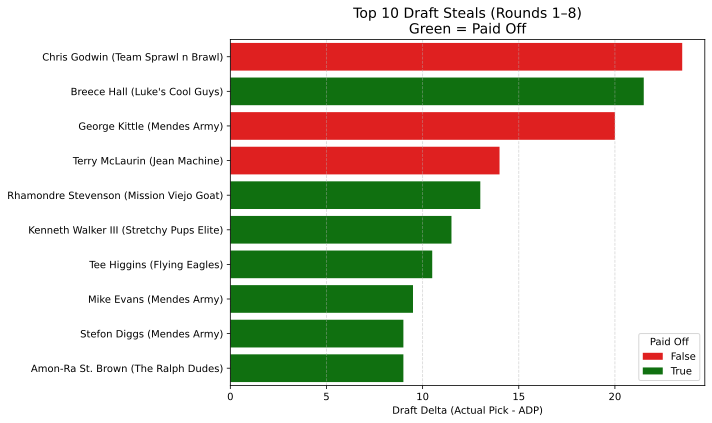

In [121]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=steals,
    y='label',
    x='draft_delta',
    hue='paid_off',
    dodge=False,  # Keep bars on same line
    palette=payoff_palette
)

plt.title("Top 10 Draft Steals (Rounds 1–8)\nGreen = Paid Off", fontsize=14)
plt.xlabel("Draft Delta (Actual Pick - ADP)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title="Paid Off")
plt.tight_layout()
plt.savefig("../docs/charts/steals_paid_off.png")
plt.show()


#### Chart showing the total VORP by Position

This breakdown calculates the Value Over Replacement Player (VORP) for each position, using only players who started most weeks.

By isolating positional VORP:

We can identify which positions were most difficult to find value at

It contextualizes which positions had more draft importance or volatility

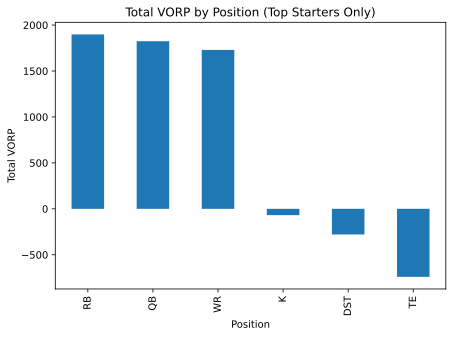

In [122]:
import matplotlib.pyplot as plt

total_vorp_by_position.plot(kind='bar', title='Total VORP by Position (Top Starters Only)')
plt.ylabel('Total VORP')
plt.xlabel('Position')
plt.tight_layout()
plt.savefig("../docs/charts/vorp_by_pos.png")
plt.show()


#### Creates a steal and reach HTML table to be displayed on the website

This final step combines earlier logic to export styled and formatted tables as standalone HTML files.
These are designed to be dropped directly into the project’s web front-end, complete with:

Player name, team, draft delta

Whether the pick paid off

Clean formatting for readability



In [123]:
cols = ['player_name', 'team_name', 'avg', 'overallPickNumber','pro_team', 'points','draft_delta']

# Top reaches: drafted much earlier than ADP
top_reaches = (
    heatmap_df[heatmap_df['draft_delta'].notnull()]
    .sort_values('draft_delta')
    .head(10)[cols]
    .reset_index(drop=True)
)

# Top falls: drafted much later than ADP
top_steals = (
    heatmap_df[heatmap_df['draft_delta'].notnull()]
    .sort_values('draft_delta', ascending=False)
    .head(10)[cols]
    .reset_index(drop=True)
)

reach_html = (
    top_reaches.style
    .set_caption("Top 10 Reaches (Drafted Before ADP)")
    .format({'avg': '{:.1f}', 'overallPickNumber': '{:.0f}', 'draft_delta': '{:.1f}'})
    .to_html()
)

# Steal table (positive draft_delta)
steal_html = (
    top_steals.style
    .set_caption("Top 10 Draft Steals (Drafted After ADP)")
    .format({'avg': '{:.1f}', 'overallPickNumber': '{:.0f}', 'draft_delta': '{:.1f}'})
    .to_html()
)

# Save tables
with open("../docs/tables/draft_reaches.html", "w") as f:
    f.write(reach_html)

with open("../docs/tables/draft_steals.html", "w") as f:
    f.write(steal_html)

top_reaches

,player_name,team_name,avg,overallPickNumber,pro_team,points,draft_delta
0,Joshua Kelley,Stretchy Pups Elite,274.0,136,LAC,44.0,-138.0
1,Keaontay Ingram,Jean Machine,262.0,168,KC,6.0,-94.0
2,Mac Jones,South Bay Starr Power,227.0,134,JAX,99.0,-93.0
3,Deshaun Watson,Gerald Pea's Football Team,77.5,5,CLE,82.0,-72.5
4,Mike Gesicki,Ambler Thighs,234.0,163,CIN,30.0,-71.0
5,Geno Smith,Flying Eagles,127.5,61,SEA,218.0,-66.5
6,Gus Edwards,The Ralph Dudes,219.5,165,LAC,165.0,-54.5
7,Seahawks D/ST,Ambler Thighs,201.0,150,SEA,84.0,-51.0
8,Damien Harris,Mission Viejo Goat,165.0,118,BUF,14.0,-47.0
9,Kyler Murray,Luke's Cool Guys,196.0,152,ARI,140.0,-44.0
